### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Step 1
def get_label_array(N, p):
    label_base = np.random.rand(N)
    return [1 if val < p else 0 for val in label_base]

In [3]:
# Step 2
def get_data(N, epsilon, p):
    labels = get_label_array(N, p)
    mu_0 = np.array([0, 0])
    mu_1 = np.array([epsilon, 0])
    sigma_0 = .5 * np.identity(2)
    sigma_1 = .4 * np.identity(2)
    x = []
    for l in labels:
        if l:
            sample = np.random.multivariate_normal(mu_1, sigma_1)
        else:
            sample = np.random.multivariate_normal(mu_0, sigma_0)
        x.append(sample)
        
    return np.array(x), labels

# Training data
D_train, labels_train = get_data(50, 2, .3)
# Testing data
D_test, labels_test = get_data(10**3, 2, .3)

print(D_train, D_test)


[[ 1.17638385 -1.17421037]
 [ 0.48239088  0.4787197 ]
 [ 2.41548942  0.10258291]
 [ 0.04686337  0.14275262]
 [-0.21063498  0.20261658]
 [-0.20282425 -0.1393318 ]
 [ 1.21914301  1.28356421]
 [ 1.19025865 -1.55422971]
 [ 2.4339086   0.49249401]
 [ 2.41774501  0.48434562]
 [ 0.97705594  0.38605366]
 [-1.20085247  0.53340705]
 [ 2.63228102 -0.53917604]
 [ 2.46538715 -0.10439612]
 [ 0.22609116  0.63005578]
 [-1.24130159  0.09015503]
 [ 2.40656569  0.041242  ]
 [-0.0254759   0.41235946]
 [ 1.03894591  0.68625218]
 [ 2.80130791 -0.97794979]
 [ 1.76573673 -0.43179253]
 [ 0.73069323 -0.14671678]
 [ 0.16891073  1.11773314]
 [-0.25026183  0.16876495]
 [ 0.5277215   0.78302109]
 [ 0.57628231  0.34491105]
 [ 0.53601822 -0.79377959]
 [-0.75247708  0.72224069]
 [ 0.54705188  0.26952157]
 [ 0.42299363 -1.2064503 ]
 [ 2.25578749  0.85825373]
 [-0.82678331 -0.44347542]
 [-0.22990664 -0.60399226]
 [ 0.0627967  -0.25371073]
 [-1.45946414  0.99513199]
 [-1.3702358   0.36836514]
 [ 2.40526424  0.04625369]
 

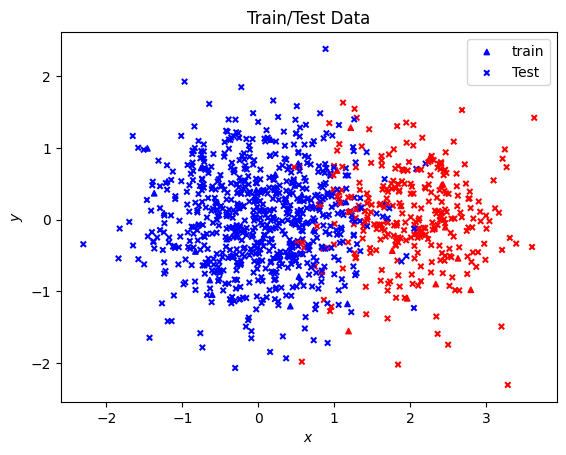

In [7]:
# Train points
plt.scatter(D_train[:, 0], D_train[:, 1],
            c=labels_train, cmap='bwr',
            marker='^', s=15, label='train')

# Test points
plt.scatter(D_test[:, 0], D_test[:, 1],
            c=labels_test, cmap='bwr',
            marker='x', s=15, label='Test')

plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Train/Test Data")
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

## Bayes Classifier and Decision Boundary

### Likelihoods

For each class:
\begin{equation*}
f_0(\mathbf{x}) = \frac{1}{2\pi \sqrt{\det \Sigma_0}}
\exp\left(-\tfrac{1}{2}(\mathbf{x}-\mu_0)^\top \Sigma_0^{-1}(\mathbf{x}-\mu_0)\right)
\end{equation*}

\begin{equation*}
f_1(\mathbf{x}) = \frac{1}{2\pi \sqrt{\det \Sigma_1}}
\exp\left(-\tfrac{1}{2}(\mathbf{x}-\mu_1)^\top \Sigma_1^{-1}(\mathbf{x}-\mu_1)\right)
\end{equation*}

### Bayes Classifier

Classify $\mathbf{x}$ as class 1 if:
\begin{equation*}
\frac{f_1(\mathbf{x})\times p}{f_0(\mathbf{x})\times(1-p)} > 1
\end{equation*}

Equivalently, using logs:
\begin{equation*}
g(\mathbf{x}) > 0
\end{equation*}

where

\begin{equation*}
g(\mathbf{x}) =
\log\frac{p}{1-p}

+ \log\sqrt{\frac{\det \Sigma_0}{\det \Sigma_1}}

- \tfrac{1}{2}(\mathbf{x}-\mu_1)^\top \Sigma_1^{-1}(\mathbf{x}-\mu_1)

+ \tfrac{1}{2}(\mathbf{x}-\mu_0)^\top \Sigma_0^{-1}(\mathbf{x}-\mu_0)
\end{equation*}

### With Given Parameters

$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0\\0\end{array}\right] \\
\quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \\
\quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] = .5 * I_2 \\
\quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right] = .4 * I_2 \\
$$

\begin{equation*}
\sqrt{\det \Sigma_0} = 0.5, \quad \sqrt{\det \Sigma_1} = 0.4
\end{equation*}

So $g$ becomes:

\begin{align*}
g(\mathbf{x}) &=
\log\frac{p}{1-p}

+ \log\left(\frac{5}{4}\right)

- \tfrac{1}{2}*\tfrac{10}{4}|\mathbf{x} - (\varepsilon,0)|^2

+ \tfrac{1}{2}*\tfrac{10}{5}|\mathbf{x}|^2\\

&=
\log\frac{p}{1-p}

+ \log\left(\frac{5}{4}\right)

- \tfrac{5}{4}|\mathbf{x} - (\varepsilon,0)|^2

+ |\mathbf{x}|^2
\end{align*}


### Decision Boundary

The decision boundary is given by:
\begin{equation*}
g(\mathbf{x}) = 0
\end{equation*}

So, 

\begin{equation*}
\log\frac{p}{1-p}

+ \log\left(\frac{5}{4}\right)

- \tfrac{5}{4}|\mathbf{x} - (\varepsilon,0)|^2

+ |\mathbf{x}|^2 = 0
\end{equation*}

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [23]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import validate_data, check_is_fitted
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import euclidean_distances
class BayesClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, p, epsilon):
        self.p = p
        self.epsilon = epsilon

        self.mu_0 = np.array([.0, .0])
        self.mu_1 = np.array([self.epsilon, .0])
        self.sigma_0 = .5 * np.identity(2)
        self.sigma_1 = .4 * np.identity(2)
        self.sq_det_0 = np.sqrt(np.linalg.det(self.sigma_0))
        self.sq_det_1 = np.sqrt(np.linalg.det(self.sigma_1))
        self.sigma_0_inv = np.linalg.inv(self.sigma_0)
        self.sigma_1_inv = np.linalg.inv(self.sigma_1)


    def fit(self, X, y):
        # Check that X and y have correct shape, set n_features_in_, etc.
        # if X and y:
        #     X, y = validate_data(self, X, y)
        
        # Return the classifier
        return self
    
    def g(self, X):
        p_term = np.log(self.p / (1 - self.p))
        det_term = np.log(self.sq_det_0 / self.sq_det_1)
        
        diff1 = X - self.mu_1
        diff0 = X - self.mu_0
        
        quad1 = np.sum(diff1 @ self.sigma_1_inv * diff1, axis=1)
        quad0 = np.sum(diff0 @ self.sigma_0_inv * diff0, axis=1)

        return p_term + det_term - 0.5 * quad1 + 0.5 * quad0
    
    def predict(self, X):
        # Check if fit has been called
        # check_is_fitted(self)
        # Input validation
        X = validate_data(self, X, reset=False)

        return (self.g(X) > 0).astype(int)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

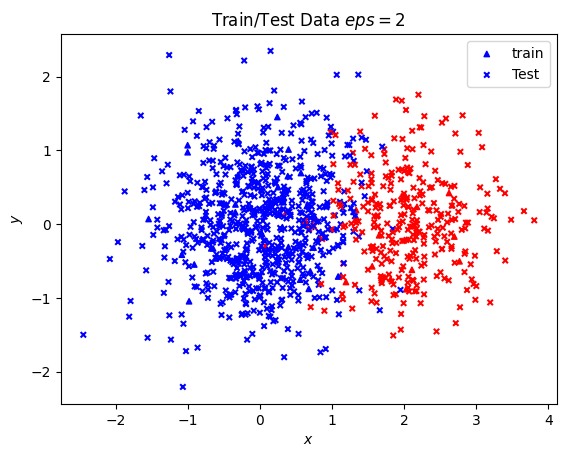

Accuracy: 0.955
Bayes error estimate: 0.04500000000000004


In [30]:
# epsilon = 2
# Generate data
D_train, labels_train = get_data(50, 2, 0.3)
D_test, labels_test = get_data(10**3, 2, 0.3)

# Train classifier
clf = BayesClassifier(p=0.3, epsilon=2.0)
clf.fit(D_train, labels_train)

# Compute accuracy and error
accuracy = clf.score(D_test, labels_test)
error = 1 - accuracy

# Train points
plt.scatter(D_train[:, 0], D_train[:, 1],
            c=labels_train, cmap='bwr',
            marker='^', s=15, label='train')

# Test points
plt.scatter(D_test[:, 0], D_test[:, 1],
            c=labels_test, cmap='bwr',
            marker='x', s=15, label='Test')

plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Train/Test Data $eps = 2$")
plt.show()

print("Accuracy:", accuracy)
print("Bayes error estimate:", error)

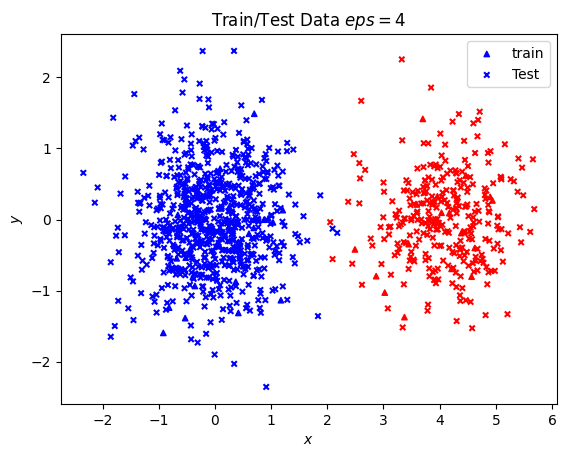

Accuracy: 0.998
Bayes error estimate: 0.0020000000000000018


In [31]:
# epsilon = 4
# Generate data
D_train, labels_train = get_data(50, 4, 0.3)
D_test, labels_test = get_data(10**3, 4, 0.3)

# Train classifier
clf = BayesClassifier(p=0.3, epsilon=4.0)
clf.fit(D_train, labels_train)

# Compute accuracy and error
accuracy = clf.score(D_test, labels_test)
error = 1 - accuracy

# Train points
plt.scatter(D_train[:, 0], D_train[:, 1],
            c=labels_train, cmap='bwr',
            marker='^', s=15, label='train')

# Test points
plt.scatter(D_test[:, 0], D_test[:, 1],
            c=labels_test, cmap='bwr',
            marker='x', s=15, label='Test')

plt.legend()
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Train/Test Data $eps = 4$")
plt.show()

print("Accuracy:", accuracy)
print("Bayes error estimate:", error)

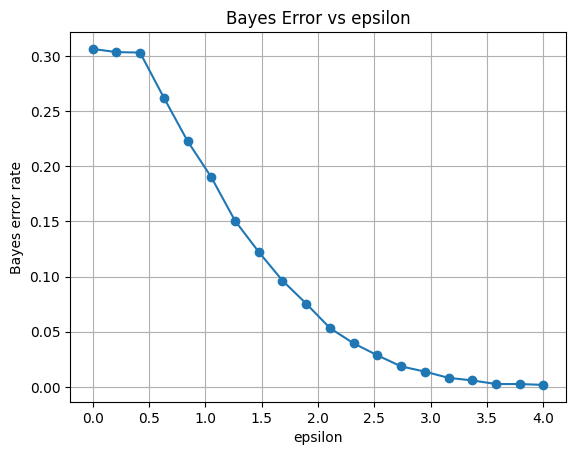

In [32]:
import matplotlib.pyplot as plt

epsilons = np.linspace(0, 4, 20)
errors = []
p = .3
for eps in epsilons:
    # Generate new dataset for each epsilon
    D_test, labels_test = get_data(10**4, eps, p)
    
    clf = BayesClassifier(p=p, epsilon=eps)
    clf.fit(None, None)
    
    error = 1 - clf.score(D_test, labels_test)
    errors.append(error)

plt.figure()
plt.plot(epsilons, errors, marker='o')
plt.xlabel("epsilon")
plt.ylabel("Bayes error rate")
plt.title("Bayes Error vs epsilon")
plt.grid(True)
plt.show()

The curve is monotonically decreasing with a sharp drop for small ε, then flattening
Error approaches 0 as separation becomes large

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?